## Masked Arrays in SciPy.

- Masked arrays are arrays that have certain elements "masked" (hidden or ignored). These elements are treated as invalid or missing and are excluded from operations like sum, mean, etc.

- In real-world data, there are often missing, corrupted, or placeholder values (like -999 or NaN). Masked arrays let you exclude those values during computations without modifying the original data.

- Masked arrays can be created directly with a mask or using helper functions like masked_equal, masked_where, etc.

- Masked arrays store both: .data: the full data array and .mask: boolean array showing masked positions.

- Arithmetic Ignores Masked Values: Math operations skip masked elements and do not include them in the result.

- When doing operations, any masked element propagates — meaning if one input is masked, the result will be masked too.

- Use .filled(value) to replace masked elements with a specific value, e.g., when saving or converting to plain arrays.

- The .compressed() method returns a 1D array with all unmasked (valid) elements, helpful for plotting or external use.

- You can mask elements dynamically based on a condition — for example, values less than 0 or greater than a threshold.

- Functions like .mean(), .sum(), .std() automatically ignore masked elements in computations.

- Masked arrays also support multi-dimensional data. You can mask specific cells, rows, or columns.


- In real-world data, missing values (e.g., sensor errors, undefined values) are common. Masked arrays allow you to mark and ignore such data without removing or altering the structure.

- Operations like sum, mean, std, etc., exclude masked values, avoiding errors or incorrect statistics due to invalid data.

- Unlike filtering, which removes data, masked arrays preserve the original shape and indexing, which is crucial for matrix operations and time-series alignment.


- You can use conditional logic to mask elements based on multiple criteria, simplifying data pre-processing.

- You can mask elements in multi-dimensional arrays, such as entire rows, columns, or cells — useful in matrix-based computations or geospatial data.

- Masked arrays are fully compatible with NumPy, so you can use them in libraries like SciPy, matplotlib, or pandas without conversions.

- You can use .filled() to replace masked values with a default or imputed value when saving or modeling.

- Before feeding data into ML models, masking helps identify and clean data points, reducing bias and improving performance.



In [ ]:
#1) Masked Arrays Example.

import numpy.ma as ma

arr = ma.array([1, 2, 3, 999, 5], mask=[0, 0, 0, 1, 0])
print(arr)  # Output: [1 2 3 -- 5]


In [29]:
#2) Masking Specific Values Using masked_equal in NumPy.


import numpy as np           # Import NumPy for array operations
import numpy.ma as ma        # Import the Masked Array Module from NumPy.
# Create a regular NumPy array with a placeholder value (-999) representing invalid data
data = np.array([10, -999, 30])

# Use masked_equal to mask all instances of -999 in the array
# Any occurrence of -999 will be replaced by a masked (hidden) value
masked = ma.masked_equal(data, -999)

# Print the masked array
# Output: -999 is masked and displayed as --
print(masked)  # Output: [10 -- 30]


[10 -- 30]


In [19]:
#3) Using masked_where to Mask Specific Elements in a NumPy Array

import numpy.ma as ma  # Import the Masked Array Module from NumPy.

# Create a masked array using masked_where
# The first argument is the condition (mask): True means the value will be masked
# The second argument is the data array
arr = ma.masked_where([False, True, False], [1, 2, 3])

# Print the resulting masked array
# Output: 2 is masked because its corresponding condition is True
print(arr)  # Output: [1 -- 3]


[1 -- 3]


In [28]:
#4) Accessing Data and Masks.

import numpy.ma as ma  # Import the Masked Array Module from NumPy.
masked = ma.masked_equal([1, -1, 3], -1)
print("Data:", masked.data)
print("Mask:", masked.mask)


Data: [ 1 -1  3]
Mask: [False  True False]


In [22]:
#5) Arithmetic Ignores Masked Values.

import numpy.ma as ma  # Import the Masked Array Module from NumPy.
a = ma.array([1, 2, 3], mask=[0, 1, 0])
b = ma.array([3, 2, 1])
print(a + b)  # Output: [4 -- 4]


[4 -- 4]


In [23]:
#6) Automatic Mask Propagation.

import numpy.ma as ma  # Import the Masked Array Module from NumPy.
x = ma.array([10, 20, 30], mask=[0, 1, 0])
y = ma.array([1, 2, 3])
result = x * y
print(result)  # Output: [10 -- 90]


[10 -- 90]


In [27]:
#7) Filling Masked Values.

import numpy.ma as ma  # Import the Masked Array Module from NumPy.
masked = ma.masked_equal([1, -1, 3], -1)
print(masked.filled(0))  # Output: [1 0 3]


[1 0 3]


In [25]:
#8) Removing Masked Elements(Compressed).

import numpy.ma as ma  # Import the Masked Array Module from NumPy.
data = ma.array([1, 2, 3, -1], mask=[0, 0, 0, 1])
print(data.compressed())  # Output: [1 2 3]


[1 2 3]


In [26]:
#9) Conditional Masking.

import numpy.ma as ma  # Import the Masked Array Module from NumPy.
data = np.array([5, 10, 15, 20])
masked = ma.masked_greater(data, 12)
print(masked)  # Output: [5 10 -- --]


[5 10 -- --]


In [30]:
#10) Aggregation Functions Work Automatically.

import numpy.ma as ma  # Import the Masked Array Module from NumPy.
a = ma.array([1, 2, 3, -999], mask=[0, 0, 0, 1])
print("Mean:", a.mean())  # Output: 2.0
print("Sum:", a.sum())    # Output: 6


Mean: 2.0
Sum: 6


In [31]:
#11) Working with 2D Masked Arrays.

import numpy.ma as ma  # Import the Masked Array Module from NumPy.
matrix = ma.array([[1, 2], [3, -999]], mask=[[0, 0], [0, 1]])
print(matrix)  # Output: [[1 2] [3 --]]


[[1 2]
 [3 --]]


In [11]:
#13) Handle Missing or Invalid Data Gracefully.

import numpy.ma as ma
data = ma.masked_equal([12, -999, 18], -999)
print(data)  # Output: [12 -- 18]


[12 -- 18]


In [12]:
#14) Perform Safe Mathematical Operations.

arr = ma.masked_equal([5, -999, 15], -999)
print("Mean:", arr.mean())  # Output: 10.0


Mean: 10.0


In [13]:
#15) Maintain Array Shape(Unlike Filtering).

arr = ma.masked_where([False, True, False], [10, 20, 30])
print(arr[1])  # Output: --


--


In [34]:
#16) Simplify Complex Condition-Based Filtering.

import numpy.ma as ma
import numpy as np

# Convert the data to a NumPy array for element-wise comparison
arr = np.array([3, 10, 20])

# Mask all elements that are less than 10
data = ma.masked_where(arr < 10, arr)

# Print the result: values less than 10 are masked
print(data)  # Output: [-- 10 20]


[-- 10 20]


In [15]:
#17) Prevent Errors in Aggregated Results.

arr = ma.masked_values([100, -999, 200, -999], -999)
print("Sum:", arr.sum())  # Output: 300


Sum: 300


In [16]:
#18) Allow Selective Masking Across Dimensions.

arr = ma.array([[1, 2], [3, 4]], mask=[[0, 1], [0, 0]])
print(arr)  # Output: [[1 --] [3 4]]


[[1 --]
 [3 4]]


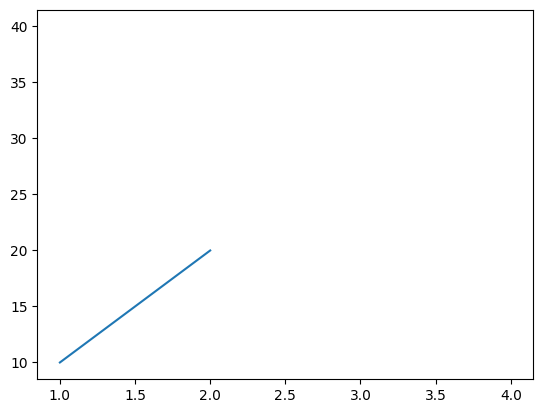

In [17]:
#19) Integrated With NumPy and SciPy Ecosystems.

import matplotlib.pyplot as plt

x = [1, 2, 3, 4]
y = ma.masked_array([10, 20, -999, 40], mask=[0, 0, 1, 0])
plt.plot(x, y)  # Plots with missing data as a gap
plt.show()


In [18]:
#20) Enable Imputation or Substitution of Missing Data.

arr = ma.masked_equal([1, -1, 3], -1)
filled_arr = arr.filled(0)
print(filled_arr)  # Output: [1 0 3]


[1 0 3]


## Examples of Masked Arrays in SciPy. 

In [58]:
#1) Example 1.

import numpy.ma as ma
arr = ma.array([1, 2, -1], mask=[0, 0, 1])
print(arr)  # Output: [1 2 --]


[1 2 --]


In [60]:
#2) Example 2.

import numpy as np
data = np.array([10, -999, 30])
masked = ma.masked_equal(data, -999)
print(masked)  # Output: [10 -- 30]


[10 -- 30]


In [63]:
#3) Example 3.

arr = ma.array([10, 20, 30], mask=[0, 1, 0])
print(arr)  # Output: [10 -- 30]


[10 -- 30]


In [70]:
#4) Example 4 - Use masked_where() to Apply Conditions.

arr = ma.masked_where([3, 10, 20] < np.array(10), [3, 10, 20])
print(arr)  # Output: [-- 10 20]


[-- 10 20]


In [71]:
#5) Example 5 - masked_equal() for Specific Values.

arr = ma.masked_equal([100, -999, 200], -999)
print(arr)  # Output: [100 -- 200]


[100 -- 200]


In [72]:
#6) Example 6 - mask Attribute.

arr = ma.array([1, 2, 3], mask=[0, 1, 0])
print(arr.mask)  # Output: [False  True False]


[False  True False]


In [73]:
#7) Example 7 - Arithmetic Ignores Masked Values.

a = ma.array([1, 2, 3], mask=[0, 1, 0])
b = ma.array([10, 10, 10])
print(a + b)  # Output: [11 -- 13]


[11 -- 13]


In [74]:
#8) Example  -  Masked Arrays Support Multi - Dimensional Data.

matrix = ma.array([[1, 2], [3, -999]], mask=[[0, 0], [0, 1]])
print(matrix)  # Output: [[1 2] [3 --]]


[[1 2]
 [3 --]]


## Support for Missing or Invalid Data.

- Masked Arrays allow certain elements to be marked as "invalid" or "missing" using a mask, so operations ignore these values automatically.

In [35]:
import numpy.ma as ma
arr = ma.array([5, -999, 10], mask=[0, 1, 0])
print(arr)  # Output: [5 -- 10]


[5 -- 10]


## Boolean Mask Representation.

- Masked Arrays use a boolean mask (same shape as the data) where True indicates a masked (invalid) value and False means valid.

In [36]:
arr = ma.array([1, 2, 3], mask=[False, True, False])
print("Mask:", arr.mask)  # Output: [False  True False]


Mask: [False  True False]


## Convenient Masking Functions.

- The numpy.ma module provides easy-to-use helper functions like masked_equal, masked_greater, masked_where for quick masking.

In [37]:
arr = ma.masked_greater([1, 5, 10, 15], 10)
print(arr)  # Output: [1 5 10 --]


[1 5 10 --]


## Arithmetic Ignores Masked Values.

- All arithmetic operations automatically skip masked values, preventing errors or contamination in results.

In [38]:
a = ma.array([1, 2, 3], mask=[0, 1, 0])
b = ma.array([3, 3, 3])
print(a + b)  # Output: [4 -- 6]


[4 -- 6]


## Aggregation Functions Respect the Mask.

- Functions like .mean(), .sum(), .std() are designed to ignore masked values while calculating the result.

In [39]:
arr = ma.array([10, -999, 30], mask=[0, 1, 0])
print("Mean:", arr.mean())  # Output: 20.0


Mean: 20.0


## Supports Multi-dimensional Arrays.

- Masked arrays support any number of dimensions, and masks can be applied to specific cells, rows, or columns.

In [40]:
matrix = ma.array([[1, 2], [3, -1]], mask=[[0, 0], [0, 1]])
print(matrix)  # Output: [[1 2] [3 --]]


[[1 2]
 [3 --]]


## Fill Masked Values with Defaults.

- Use .filled(value) to replace all masked values with a specific placeholder or imputed value.

In [41]:
arr = ma.masked_equal([1, -1, 3], -1)
print(arr.filled(0))  # Output: [1 0 3]


[1 0 3]


## Compress Function to Remove Masked Elements.

- .compressed() removes all masked elements and returns a flattened array with only valid values.

In [42]:
arr = ma.array([10, 20, -999], mask=[0, 0, 1])
print(arr.compressed())  # Output: [10 20]


[10 20]


## Conditional Masking Support.

- You can dynamically mask elements based on any condition(e.g., values less than 0, greater than a threshold, etc.)

In [75]:
import numpy.ma as ma
import numpy as np

# Convert the list to a NumPy array for element-wise comparison
arr = np.array([1, 2, -1, 4])

# Mask the values that are less than 0
data = ma.masked_where(arr < 0, arr)

# Print the masked array
print(data)  # Output: [1 2 -- 4]



[1 2 -- 4]


## Compatible with Visualization Libraries.

- Masked arrays are fully compatible with matplotlib, and masked values are excluded from plots automatically.

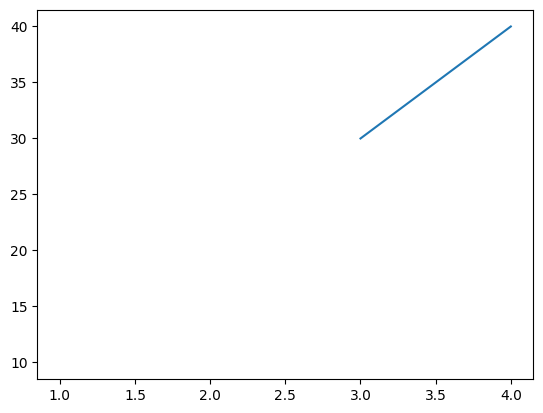

In [44]:
import matplotlib.pyplot as plt
x = [1, 2, 3, 4]
y = ma.masked_equal([10, -999, 30, 40], -999)
plt.plot(x, y)
plt.show()


## Easy Integration with NumPy/SciPy Tools.

- Masked Arrays extend regular NumPy arrays and work seamlessly with NumPy functions and SciPy algorithms, making them ideal for scientific computing.



In [45]:
from scipy.stats import zscore
arr = ma.masked_equal([100, 200, -1], -1)
zs = zscore(arr)
print(zs)  # Ignores -1 in calculation


[-1.0 1.0 --]


## Useful in data analysis when handling: Missing Values, Corrupted sensor readings and Placeholder values like -999 or NaN.



In [46]:
import numpy as np

raw_data = np.array([10, -999, 15, 20])
masked_data = ma.masked_equal(raw_data, -999)
print(masked_data)


[10 -- 15 20]


## You can create a masked array by: Providing a data array and a mask or Using Convenience Functions like masked_equal, masked_greater, etc.

In [47]:
arr = ma.masked_greater([1, 5, 10, 15], 10)
print(arr)


[1 5 10 --]


## Accessing Data and Mask : You can access  : .data: the underlying data and  .mask: the mask(Boolean Array).

In [48]:
masked = ma.masked_equal([1, -1, 3], -1)
print("Data:", masked.data)
print("Mask:", masked.mask)


Data: [ 1 -1  3]
Mask: [False  True False]


## Arithmetic with Masked Arrays i.e. Operations on masked arrays ignore masked values.

In [49]:
a = ma.masked_array([1, 2, 3], mask=[0, 1, 0])
b = ma.masked_array([3, 2, 1], mask=[0, 0, 0])
print(a + b)  # Masked value remains masked in output


[4 -- 4]


## Mask Propagation : If any operand in an operation is masked, the result is masked.

In [50]:
x = ma.masked_array([1, 2, 3], mask=[0, 1, 0])
y = ma.masked_array([4, 5, 6])
z = x + y
print(z.mask)  # Second element is masked


[False  True False]


## Filling Masked Values  : You can replace masked values with specified numbers using .filled().

In [51]:
data = ma.masked_array([10, -1, 30], mask=[0, 1, 0])
print(data.filled(0))  # Replaces masked value with 0


[10  0 30]


##  Mask Propagation  :  If any operand in an operation is masked, the result is masked.

In [52]:
x = ma.masked_array([1, 2, 3], mask=[0, 1, 0])
y = ma.masked_array([4, 5, 6])
z = x + y
print(z.mask)  # Second element is masked


[False  True False]


## Filling Masked Values  :  You can replace masked values with specified numbers using .filled().

In [53]:
data = ma.masked_array([10, -1, 30], mask=[0, 1, 0])
print(data.filled(0))  # Replaces masked value with 0


[10  0 30]


## Compressing Masked Arrays  :  Removes all Masked Elements from the Array.

In [54]:
a = ma.masked_array([1, 2, 3], mask=[0, 1, 0])
print(a.compressed())  # Output: [1 3]


[1 3]


## Masking Conditions Dynamically   :  You can apply complex conditions using boolean logic to create masks dynamically.

In [55]:
data = np.array([5, 15, 25, 35])
masked = ma.masked_where(data > 20, data)
print(masked)


[5 15 -- --]


## Working with Multidimensional Masked Arrays   :  Masks work with any dimension. You can mask rows, columns, or individual elements.

In [56]:
matrix = ma.array([[1, 2], [3, -999]], mask=[[0, 0], [0, 1]])
print(matrix)


[[1 2]
 [3 --]]


## Aggregation Functions(mean, sum, etc.)    :  Functions like mean, sum, min, etc., work like NumPy, ignoring masked values.

In [57]:
a = ma.masked_array([1, 2, 3, -999], mask=[0, 0, 0, 1])
print("Mean:", a.mean())
print("Sum:", a.sum())


Mean: 2.0
Sum: 6
